# Chapter 4: Implementing a GPT Model from Scratch to Generate Text

In this chapter, we implement a GPT-like LLM architecture; the next chapter will focus on training this LLM.

<img src="images/web01.png" width="800">

## 4.1 Coding an LLM Architecture

Chapter 1 discussed models like GPT and Llama, which generate words sequentially and are based on the decoder part of the original transformer architecture. Therefore, these LLMs are often referred to as "decoder-like" LLMs.

Compared to conventional deep learning models, LLMs are larger, mainly due to their vast number of parameters, not the amount of code. We'll see that many elements are repeated in an LLM's architecture.

<img src="images/web02.png" width="400">

In previous chapter, we consider embedding and model sizes akin to a small GPT-2 model. We'll specifically code the architecture of the smallest GPT-2 model (124 million parameters).

Chapter 6 will show how to load pretrained weights into our implementation, which will be compatible with model sizes of 345, 762, and 1542 million parameters.

Configuration details for the 124 million parameter GPT-2 model include:
- We use short variable names to avoid long lines of code later.
- `vocab_size` indicates a vocabulary size of 50,257 words, supported by the BPE tokenizer discussed in Chapter 2.
- `context_length` represents the model's maximum input token count, as enabled by positional embeddings covered in Chapter 2.
- `emb_dim` is the embedding size for token inputs, converting each input token into a 768-dimensional vector.
- `n_heads` is the number of attention heads in the multi-head attention mechanism implemented in Chapter 3.
- `n_layers` is the number of transformer blocks within the model, which we'll implement in upcoming sections.
- `drop_rate` is the dropout mechanism's intensity, discussed in Chapter 3, 0.1 means dropping 10% of hidden units during training to mitigate overfitting.
- `qkv_bias` decides if the `Linear` layers in the multi-head attention mechanism should include a bias vector when computing query, key, and value tensors; we'll disable this option, which is standard practice in modern LLMs; however, we'll revisit this later when loading pretrained GPT-2 weights from OpenAI into our reimplementation in Chapter 5.

<img src="images/web03.png" width="600">


In [44]:
import torch
import tiktoken
import torch.nn as nn

GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Use a placeholder for Transformer Block
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # Placeholder

    def forward(self, x):
        # This block does nothing and just returns its input
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        # This block does nothing and just returns its input
        return x

<img src="images/web04.png" width="600">

In [45]:
tokenizer = tiktoken.get_encoding("gpt2")
batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape: ", logits.shape)
print(logits)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output shape:  torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


## 4.2 Normalizing Activations with Layer Normalization

Layer normalization, also known as LayerNorm, centers the activations of a neural network layer around a mean of 0 and normalizes their variance to 1. This stabilizes training and enables faster convergence to effective weights.

Layer normalization is applied both before and after the multi-head attention module within the transformer block, which we will implement later; it's also applied before the final output layer.

<img src="images/web05.png" width="400">

Let's see how layer normalization works by passing a small input sample through a simple neural network layer. Let's computer the mean and variance for each of the 2 inputs above.

The normalization is applied to each of the two inputs (rows) independently; using dim=-1 applies the calculation across the last dimension instead of the row dimension.

<img src="images/web06.png" width="400">

Subtracting the mean and dividing by the square-root of the variance (standard deviation) centers the inputs to have a mean of 0 and a variance of 1 across the column dimension.

In [46]:
torch.manual_seed(123)

# Create 2 training examples with 5 dimensions each 
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print("Values before Normalization.")
print("Mean: \n", mean)
print("Variance: \n", var)

out_norm = (out - mean) / torch.sqrt(var)
print("\nNormalized layer outputs: \n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean: \n", mean)
print("Variance: \n", var)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)
Values before Normalization.
Mean: 
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance: 
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)

Normalized layer outputs: 
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean: 
 tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
Variance: 
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


Above, we normalized the features of each input. Now, using the same idea, we can implement a `LayerNorm` class.

In [47]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

torch.set_printoptions(sci_mode=False)

ln = LayerNorm(emb_dim=6)
out_ln = ln(out)

mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[     0.0000],
        [    -0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)


## 4.3 Implementing a Feed Forward Network with GELU Activations

In this section, we implement a small neural network submodule that is used as part of the transformer block in LLMs. We start with activation function.

In deep learning, ReLU (Rectified Linear Unit) activation functions are commonly used due to their simplicity and effectiveness in various neural network architectures. In LLMs, various other types of activation functions are used beyond the traditional ReLU; two notable examples are GELU (Gaussian Error Linear Unit) and SwiGLU (Swish-Gated Linear Unit).

GELU and SwiGLU are more complex, smooth activation functions incorporating Gaussian and sigmoid-gated linear units, respectively, offering better performance for deep learning models, unlike the simpler, piecewise linear function of ReLU.

GELU can be implemented in several ways, the exact version is defined as GELU(x) = x*fi(x), where fi(x) is the cumulative distribution function of the standard Gaussian distribution. In practice, it's common to implement a computationally cheaper approximation:

<img src="images/web07.png" width="600">

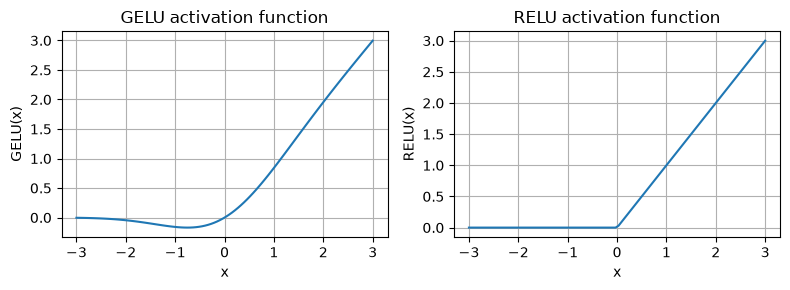

In [48]:
import matplotlib.pyplot as plt

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
        ))

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "RELU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

As we can see, ReLU is a piecewise linear function that outputs the input directly if it is positive; otherwise, it outputs zero.

GELU is a smooth, non-linear function that approximates ReLU but with a non-zero gradient for negative values. Next, let's implement the small neural network module, `FeedForward`, that we will be using in the LLM's transformer block later.

<img src="images/web08.png" width="600">

In [49]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]),
            GELU(),
            nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layers(x)

print(GPT_CONFIG_124M["emb_dim"])

ffn = FeedForward(GPT_CONFIG_124M)

# Input shape = [batch_size, num_token, emb_size]
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

768
torch.Size([2, 3, 768])


## 4.4 Adding Shortcut Connections

Next, let's talk about the concept behind shortcut connections, also called skip or residual connections. Originally, shortcut connections were proposed in deep networks for computer vision to mitigate vanishing gradient problems. 

A shortcut connection creates an alternative shorter path for the gradient to flow through the network. This is achieved by adding the output of one layer to the output of a later layer, usually skipping one or more layers in between.

<img src="images/web09.png" width="400">

In [50]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target and output are
    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()
    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

Let's print the gradient values first **without** shortcut connections.

In [51]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


Next, let's print the gradient values **with** shortcut connections.

As we can see based on the output, shortcut connections prevent the gradients from vanishing in the early layers (towards layer.0).

In [52]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.2216978669166565
layers.1.0.weight has gradient mean of 0.20694100856781006
layers.2.0.weight has gradient mean of 0.3289698660373688
layers.3.0.weight has gradient mean of 0.2665731906890869
layers.4.0.weight has gradient mean of 1.3258538246154785


## 4.5 Connecting Attention and Linear Layers in a Transformer Block

In this section, we now combine the previous concepts into a so-called transformer block. A transformer block combines the causal multi-head attention module from the previous chapter with the linear layers, the feed forward neural network we implemented in an earlier section.

In addition, the transformer block also uses dropout and shortcut connections.

In [53]:
from previous_chapter import MultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut # Add the original input back
        return x


<img src="images/web10.png" width="600">

Suppose we have 2 input samples with 4 tokens each, where each token is a 768-dimensional embedding vector; then this transformer block applies self-attention, followed by linear layers, to produce an output of similar size.

You can think of the output as an augmented version of the context vectors we discussed in the previous chapter.

In [54]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768) # Shape = [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape: ", x.shape)
print("Output shape: ", output.shape)

Input shape:  torch.Size([2, 4, 768])
Output shape:  torch.Size([2, 4, 768])


## 4.6 Coding the GPT Model

We are almost there: now let's plug in the transformer block into the architecture we coded at the very beginning of this chapter so that we obtain a usable GPT architecture. Note that the transformer block is repeated multiple times, in the case of the smallest 124M GPT-2 model, we repeat it 12 times.

<img src="images/web11.png" width="600">

In [55]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

Using the configuration of the 124M parameter model, we can now instantiate this GPT model with random initial weights as follows.

In [56]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch: ", batch)
print("\nOutput shape: ", out.shape)
print(out)

Input batch:  tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape:  torch.Size([2, 4, 50257])
tensor([[[ 0.3643, -0.5793, -0.1398,  ..., -0.0410, -0.6210, -0.1992],
         [-0.2083, -0.5990,  0.2493,  ..., -0.5646, -0.8744,  0.3403],
         [ 0.0467, -0.1488,  0.0879,  ..., -0.5768, -1.1299, -0.3036],
         [ 0.2603, -0.3070,  0.1413,  ..., -0.4282, -1.0025,  0.1100]],

        [[-0.0767, -0.3768, -0.1036,  ...,  0.6063, -0.7923, -0.1704],
         [-0.0193, -0.6299, -0.4411,  ...,  0.3890, -0.4489, -0.5461],
         [-0.1955, -0.4203, -0.1026,  ...,  0.2939, -0.2553, -0.3846],
         [-0.1147, -0.5126, -0.1201,  ...,  0.2209, -0.2919, -0.7427]]],
       grad_fn=<UnsafeViewBackward0>)


We will train this model in the next chapter. However, a quick note about its size: we previously referred to it as a 124M parameter model; we can double check this number as follows.

In [57]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Total number of parameters: 163,009,536
Number of trainable parameters considering weight tying: 124,412,160


## 4.7 Generating Text

LLMs like the GPT model we implemented above are used to generate one word at a time.

<img src="images/web12.png" width="600">

The following `generate_text_simple` function implements greedy decoding, which is a simple and fast method to generate text. In greedy decoding, at each step, the model chooses the word with the highest probability as its next output (the highest logit corresponds to the highest probability, so we technically wouldn't even have to compute the softmax function explicitly).

In the next chapter, we will implement a more advanced `generate_text` function. The figure below depicts how the GPT model, given an input context, generates the next word token.

<img src="images/web13.png" width="800">

In [58]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        # Crop current context if it exceeds the supported context size
        idx_cond = idx[:, -context_size:]
    
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        logits = logits[:, -1, :]
        
        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

The `generate_text_simple` above implements an iterative process, where it creates one token at a time.

<img src="images/web14.png" width="800">

In [59]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded: ", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape: ", encoded_tensor.shape)

model.eval() # Disable dropout
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output: ", out)

decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

encoded:  [15496, 11, 314, 716]
encoded_tensor.shape:  torch.Size([1, 4])
Output:  tensor([[15496,    11,   314,   716, 12650, 12650, 12650, 12650, 12650, 12650]])
Hello, I am patri patri patri patri patri patri


Note that the model is untrained, hence the random output texts above. We will train the model in the next chapter.